In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["AWS_ACCESS_KEY_ID"] = os.getenv("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = os.getenv("AWS_SECRET_ACCESS_KEY")
os.environ["MLFLOW_S3_ENDPOINT_URL"] = "https://storage.yandexcloud.net"

EDA

1.

In [4]:
import sys
print(sys.executable)

/home/mle-user/mle_projects/mle-project-sprint-2/venv/bin/python


In [5]:
import os
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

# ====== ЗАГРУЗКА ДАННЫХ ======
connection = {
    "sslmode": "require",
    "target_session_attrs": "read-write",
    "host": os.getenv("DB_DESTINATION_HOST"),
    "port": os.getenv("DB_DESTINATION_PORT"),
    "dbname": os.getenv("DB_DESTINATION_NAME"),
    "user": os.getenv("DB_DESTINATION_USER"),
    "password": os.getenv("DB_DESTINATION_PASSWORD"),
}

with psycopg2.connect(**connection) as conn:
    with conn.cursor() as cur:
        cur.execute("SELECT * FROM users_churn")
        data = cur.fetchall()
        columns = [col[0] for col in cur.description]

df = pd.DataFrame(data, columns=columns)
df.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,gender,senior_citizen,partner,dependents,multiple_lines,target
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,DSL,No,...,No,No,No,No,Female,0,Yes,No,None,0
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.50,DSL,Yes,...,Yes,No,No,No,Male,0,No,No,No,0
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,DSL,Yes,...,No,No,No,No,Male,0,No,No,No,1
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,DSL,Yes,...,Yes,Yes,No,No,Male,0,No,No,None,0
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Fiber optic,No,...,No,No,No,No,Female,0,No,No,No,1


2. Общая информация о данных

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        7043 non-null   object 
 1   begin_date         7043 non-null   object 
 2   end_date           7043 non-null   object 
 3   type               7043 non-null   object 
 4   paperless_billing  7043 non-null   object 
 5   payment_method     7043 non-null   object 
 6   monthly_charges    7043 non-null   float64
 7   total_charges      7032 non-null   float64
 8   internet_service   5517 non-null   object 
 9   online_security    5517 non-null   object 
 10  online_backup      5517 non-null   object 
 11  device_protection  5517 non-null   object 
 12  tech_support       5517 non-null   object 
 13  streaming_tv       5517 non-null   object 
 14  streaming_movies   5517 non-null   object 
 15  gender             7043 non-null   object 
 16  senior_citizen     7043 

3. Статистика числовых признаков

In [7]:
df.describe()

,monthly_charges,total_charges,senior_citizen,target
count,7043.000000,7032.000000,7043.000000,7043.000000
mean,64.761692,2283.300441,0.162147,0.265370
std,30.090047,2266.771362,0.368612,0.441561
min,18.250000,18.800000,0.000000,0.000000
25%,35.500000,401.450000,0.000000,0.000000
50%,70.350000,1397.475000,0.000000,0.000000
75%,89.850000,3794.737500,0.000000,1.000000
max,118.750000,8684.800000,1.000000,1.000000


Данные разнородны, есть выбросы по total_charges. Целевая переменная несбалансирована (~27% оттока)

4. Проверка пропусков

In [8]:
df.isnull().sum()

customer_id             0
begin_date              0
end_date                0
type                    0
paperless_billing       0
payment_method          0
monthly_charges         0
total_charges          11
internet_service     1526
online_security      1526
online_backup        1526
device_protection    1526
tech_support         1526
streaming_tv         1526
streaming_movies     1526
gender                  0
senior_citizen          0
partner                 0
dependents              0
multiple_lines        682
target                  0
dtype: int64

Пропуски не случайны — они связаны с отсутствием интернет-услуг у части клиентов. Это смысловые пропуски, их нужно обрабатывать аккуратно (заполнять строкой "No" или "None").

5. Распределение целевой переменной

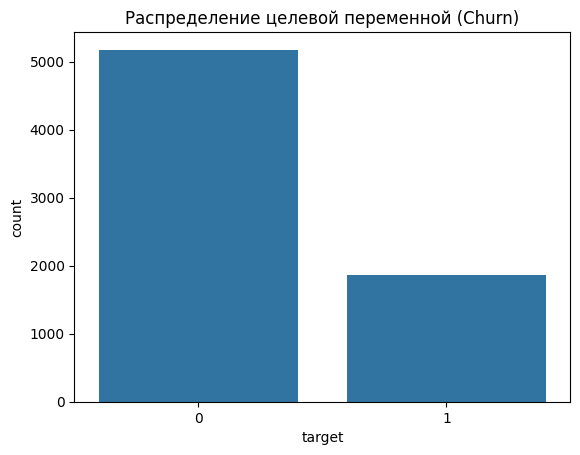

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='target')
plt.title('Распределение целевой переменной (Churn)')
plt.show()

Выводы:
1. Пропуски в данных связаны с отсутствием интернет-услуг — их нужно обрабатывать осмысленно, а не удалять.

2. Целевая переменная несбалансирована — только 27% клиентов ушли. Это важно для выбора метрики и подхода к обучению.

3. Признаки имеют разный масштаб — числовые признаки нужно масштабировать перед обучением.

6. Логи в MLflow как артефакт

In [11]:
import os
import mlflow
from dotenv import load_dotenv

load_dotenv()

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("churn_project_experiment")

with mlflow.start_run(run_name="eda_analysis") as run:
    run_id = run.info.run_id
    mlflow.log_artifact("eda.ipynb")
    print("✅ EDA блокнот залогирован")
    print("🔗 Run ID:", run_id)

✅ EDA блокнот залогирован
🔗 Run ID: ec48c2a516914c41bb82002f053829b6


In [12]:
import mlflow
from mlflow.tracking import MlflowClient

client = MlflowClient()

run_id = "ec48c2a516914c41bb82002f053829b6"

artifacts = client.list_artifacts(run_id)

print("Артефакты в запуске:")
for a in artifacts:
    print(f" - {a.path} ({a.file_size} bytes)")

Артефакты в запуске:
 - eda.ipynb (42111 bytes)
